**Práctica 1** Análisis exploratorio de dataset.

*Introducción a Ciencia de Datos*

***María Guadalupe Villanueva Utrilla***

**Descripción y procedencia de dataset**

El dataset empleado para esta primer práctica ha sido recolectado por la empresa Airbnb, la cual contiene datos recabados de las experiencias de los clientes en la Ciudad de México, expresado en fecha 15 de junio de 2026. Este dataset está compuesto por 31431 registros, cada una caracterizada con un respectivo id. Está conformado por algunos de los siguientes atributos: *id, listing_url, scrape_id, last_scraped, source, name, description, neighborhood_overview, picture_url, host_id, host_url, host_profile_id, host_profile_url, host_name, host_since, hosts_time_as_user_years, hosts_time_as_user_months, etc*.




**Estos datos han sido recolectados por Inside Airbnb**

(https://insideairbnb.com/get-the-data/); con listado individual como unidad de observación.


## Licencia y Atribución
Los datos utilizados en este proyecto provienen de [Inside Airbnb](https://insideairbnb.com/) y están protegidos bajo la licencia [Creative Commons Attribution 4.0 International License (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/).

* Cita: *Inside Airbnb. (2026). Mexico City, Distrito Federal, Mexico listings data (15 June 2026).*

In [3]:
  #Verificación de dataset#

#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

#Carga de datos
df = pd.read_csv('listings.csv')

#Verificación de la estructura
print(f"Dimensiones: {df.shape [0]} registros (filas) y {df.shape[1]} atributos(columnas).")
print("\nTipos de atributo:")
print(df.dtypes)


Dimensiones: 31430 registros (filas) y 90 atributos(columnas).

Tipos de atributo:
id                                                int64
listing_url                                      object
scrape_id                                         int64
last_scraped                                     object
source                                           object
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 90, dtype: object


Valores faltantes
neighborhood_overview           31430
host_since                      31430
host_total_listings_count       31430
neighbourhood                   31430
host_verifications              31430
host_response_rate              31430
host_acceptance_rate            31430
host_thumbnail_url              31430
host_response_time              31430
host_neighbourhood              31430
instant_bookable                31430
license                         31430
neighbourhood_group_cleansed    31430
calendar_updated                31430
host_about                      12906
host_location                    7071
review_scores_accuracy           5500
review_scores_communication      5500
review_scores_checkin            5500
review_scores_location           5500
review_scores_value              5500
reviews_per_month                5499
first_review                     5499
review_scores_cleanliness        5499
review_scores_rating             5499
last_review                     

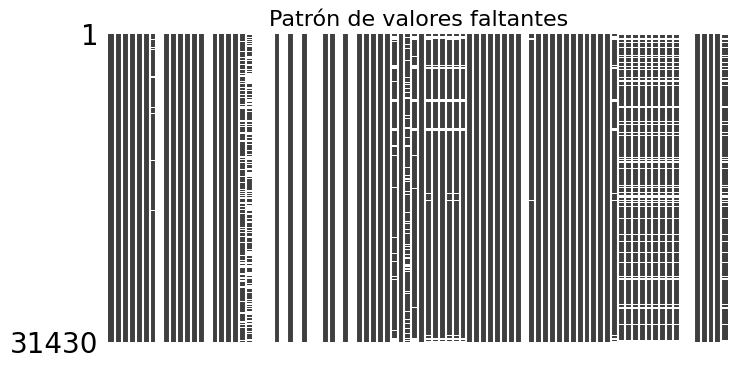

In [4]:
  #Análisis de calidad de los datos
#Valores faltantes
print("Valores faltantes")
miss = df.isnull().sum()
print(miss[miss>0].sort_values(ascending=False))

#Patrón
#plt.figure(figsize=(8, 4))
msno.matrix(df, figsize=(8, 4), sparkline=False)
plt.title("Patrón de valores faltantes", fontsize=16)
plt.show()



**14 atributos** por mencionar algunos: host_since, host_response_rate, host_acceptance_rate, license, neighbourhood_group_cleansed, calendar_updated, entre otros más tienen 31,430 valores nulos. Esto significa el total de atributos del dataset en esos registros está vacío.

    Se deben eliminar del dataset antes del análisis, ya que no dan ninguna información y solo consumen recursos.



Podría corresponder a nuevas listas o que no han recibido ninguna reseña por parte de los huéspedes.


In [5]:
#Duplicados
print("Duplicados")
print(f"Registris duplicadas exactas: {df.duplicated().sum()}")
print(f"IDs de listados duplicados: {df['id'].duplicated().sum()}")


Duplicados
Registris duplicadas exactas: 0
IDs de listados duplicados: 0


No se registró ningún duplicado.

El `id` sí funciona como un identificador único válido para cada observación. Por lo que no se necesita ninguna eliminación de registros por duplicación.

In [6]:
#Valores imposibles
print("Valores imposibles")
if df['price'].dtype == 'O':
    df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

#
print(f"Lugares con precio = 0: {(df['price'] == 0).sum()}")
print(f"Lugares con número de noches mínimas > 365: {(df['minimum_nights'] > 365).sum()}")
print(f"Disponibilidad o > 365: {((df['availability_365'] < 0) | (df['availability_365'] > 365)).sum()}")



Valores imposibles
Lugares con precio = 0: 0
Lugares con número de noches mínimas > 365: 5
Disponibilidad o > 365: 0


No hay alojamientos con costo de $0 pesos.

La variable `availability_365` no presenta ningún valor fuera del rango permitido que serían de 0 a 365 días, con lo que se valida el cálculo de disponibilidad anual.


Se encontraron 5 propiedades con una exigencia de estancia mínima superior a un año (`minimum_nights > 365`). Una estancia mínima de este tipo no es congruente con el propósito de airbnb, por lo cual podría indicar un error de captura, o bien, que han querido bloquear la propiedad, por lo que se borrarán.

In [7]:
#Cardinalidad de atributos categóricos
categoricas = df.select_dtypes(include=['object', 'category']).columns
print(df[categoricas].nunique().sort_values(ascending=False))

listing_url                  31430
picture_url                  30563
name                         29847
amenities                    28909
description                  25549
price_quote_raw              24475
host_url                     14107
host_profile_url             14106
host_picture_url             13502
host_about                    7171
host_name                     5040
first_review                  3769
last_review                   1702
host_location                  469
price_quote_checkout_date      326
price_quote_checkin_date       301
property_type                   87
bathrooms_text                  58
neighbourhood_cleansed          16
room_type                        4
last_scraped                     3
calendar_last_scraped            3
source                           2
host_has_profile_pic             2
host_is_superhost                2
host_identity_verified           2
has_availability                 1
dtype: int64



Las variables como `listing_url` (31,430), `picture_url` (30,563), `name` (29,847), `amenities` (28,909) y `description` (25,549) presentan una cantidad casi igual al total de filas del dataset, por lo que se pueden interpretar como únicas por propiedad. En esta práctica las consideraremos como no útiles como variables de agrupación.

Respecto a perfiles de anfitriones (`host_url` y `host_profile_url`) hay 14,106 y 14,107 valores únicos respectivamente. Si se compara esta cantidad de anfitriones contra el total de propiedades se puede asumir que cada anfitrión administra en promedio 2.2 propiedades.


Algunas otras variables como `room_type` tiene solo 4 categorías únicas tales como *Entire home/apt*, *Private room*, *Shared room*, *Hotel room*, lo que la hace una buena variable categórica para segmentaciones bivariadas o de grupo.

`neighbourhood_cleansed` tiene 16 valores únicos, los cuales corresponden al número de alcaldías de la Ciudad de México, por lo que se puede hacer una división territorial para análisis de distribuciones geográficas.


`property_type` tiene 87 categorías, lo que indica diferentes tipos de alojamientos, algunos como departamentos, casas y lofts.

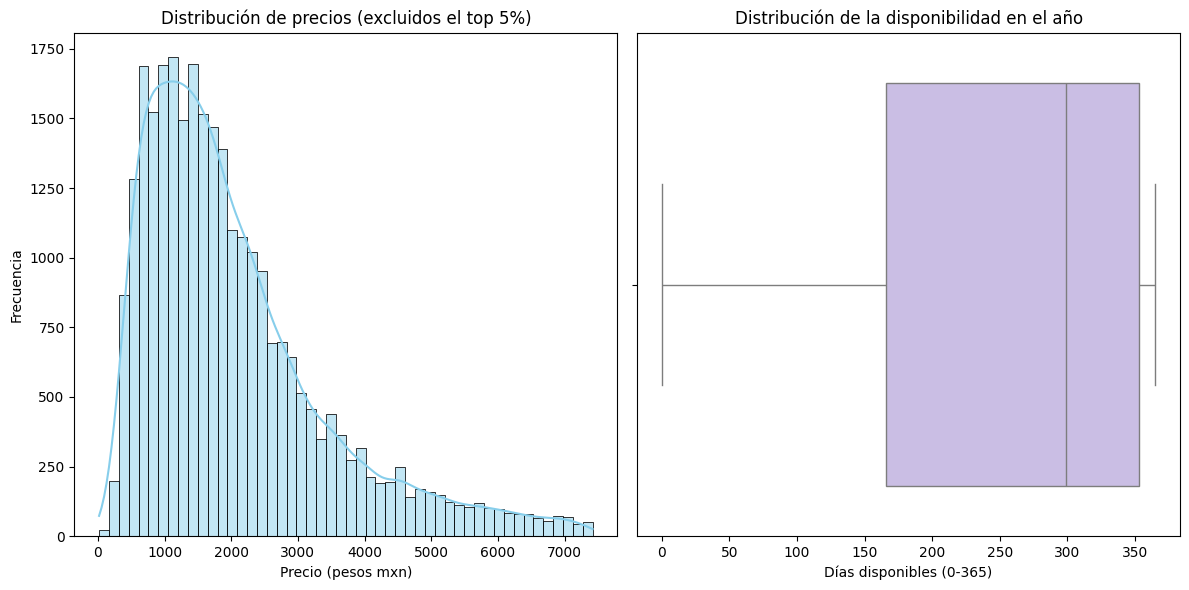

            price  minimum_nights  availability_365  number_of_reviews
count    29637.00        31419.00          31430.00           31430.00
mean      2913.69            2.90            250.38              54.72
std       9398.89           16.08            117.88              90.94
min         18.76            1.00              0.00               0.00
25%       1073.00            1.00            166.00               2.00
50%       1756.00            1.00            299.00              18.00
75%       2853.00            2.00            353.00              69.00
max    1141520.00          729.00            365.00            1739.00


In [8]:
#Filtro de valores más altos de precio
limite_precio = df['price'].quantile(0.95) #percentil 95 para facilitar la visualización
df_filtrado = df[df['price'] <= limite_precio]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#histograma de los precios
sns.histplot(df_filtrado['price'], bins=50, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribución de precios (excluidos el top 5%)')
ax[0].set_xlabel('Precio (pesos mxn)')
ax[0].set_ylabel('Frecuencia')

#Disponibilidad
sns.boxplot(x=df['availability_365'], ax=ax[1], color='#C7B8EA')
ax[1].set_title('Distribución de la disponibilidad en el año')
ax[1].set_xlabel('Días disponibles (0-365)')

plt.tight_layout()
plt.show()

# Estadísticos descriptivos más relevantes
print(df[['price', 'minimum_nights', 'availability_365', 'number_of_reviews']].describe().round(2))

Para el análisis univariado se tiene:

*Precio por Noche (`price`):* tiene un sesgo positivo. Mientras el 50% de los alojamientos cuesta $1,756.00$MXN o menos, el promedio se eleva a $2,913.69 MXN debido a valores extremos.
    Hay un valor máximo de $1,141,520.00 MXN por noche y un mínimo de $18.76 MXN. El valor máximo puede ser un error de captura o una propiedad fuera de rango.

*Noches Mínimas (`minimum_nights`):*
Con la mediana y el percentil 75 se puede interpretar que la gran mayoría de la oferta exige entre 1 y 2 noches mínimas de estancia. El promedio es de 2.90 noches.
    Hay propiedades con hasta 729 noches mínimas.

*Disponibilidad Anual (`availability_365`):*
La mediana es de 299 días y el promedio es de 250.38 días al año.
    La oferta de Airbnb en CDMX está orientada a la disponibilidad constante a lo largo del año, en lugar de alojamientos compartidos de forma ocasional.

*Número de Reseñas (`number_of_reviews`):*
Tiene una distribución que desciende. Un 25% de los listados tiene 2 o menos reseñas, mientras que el promedio alcanza 54.72 reseñas.
    Existe un núcleo concentrado de alojamientos con alta atracción de huéspedes, en comparación con una cantidad amplia de listados nuevos o con muy poco historial de reservas.

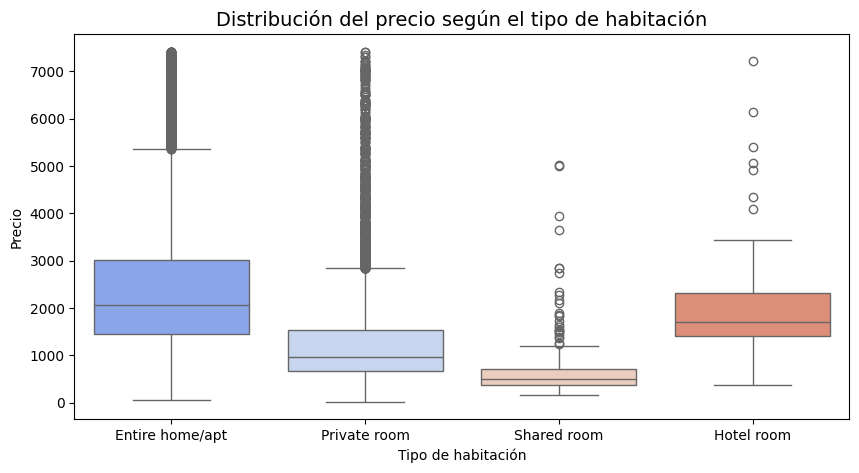

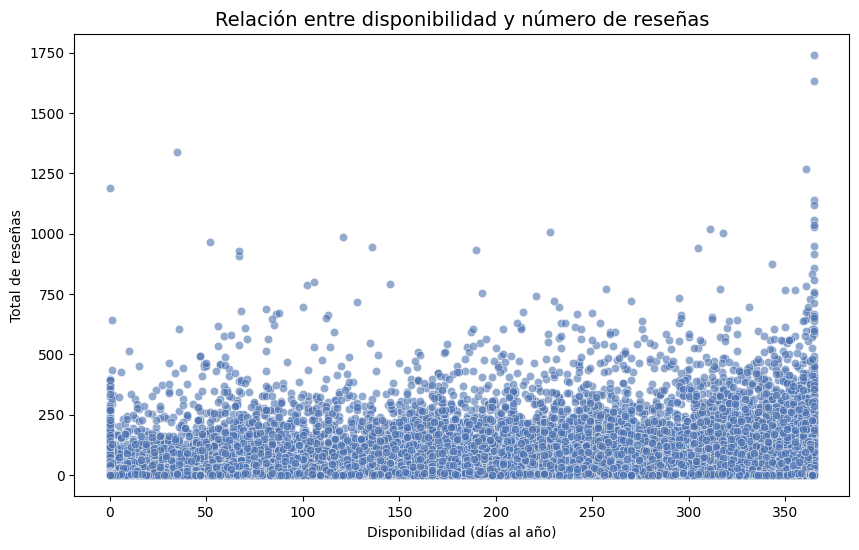

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# Boxplot de precio por tipo de habitación
sns.boxplot(x='room_type', y='price', data=df_filtrado, hue='room_type', palette='coolwarm', legend=False)
plt.title('Distribución del precio según el tipo de habitación', fontsize=14)
plt.xlabel('Tipo de habitación')
plt.ylabel('Precio')
plt.show()

# Scatterplot de reseñas vs disponibilidad
plt.figure(figsize=(10, 6))
sns.scatterplot(x='availability_365', y='number_of_reviews', data=df, alpha=0.6, color='#4C72B0' )
plt.title('Relación entre disponibilidad y número de reseñas', fontsize=14)
plt.xlabel('Disponibilidad (días al año)')
plt.ylabel('Total de reseñas')
plt.show()

En la primer gráfica se encuentran las parejas de variables Precio vs. tipo de habitación para evaluar el impacto de la privacidad en el costo por noche, y en la segunda, la disponibilidad vs. número de reseñas para identificar si la tracción de huéspedes condiciona la disponibilidad del inmueble a lo largo del año.

  Para la primer gráfica: *precio vs. tipo de habitación.*
  
  
  Los alojamientos de tipo `Entire home/apt` registran la mediana de precio más alta ($2,000$ MXN), seguidos por `Hotel room` ($1,700$ MXN), `Private room` ($950$ MXN) y `Shared room` ($500$ MXN).   
  
  El grupo Entire home/apt presenta la mayor dispersión intermedia y la mayor densidad de valores no típicos superiores con propiedades que alcanzan hasta los $7,500 MXN. Las habitaciones compartidas y privadas mantienen una distribución de precios mucho más económica.   
  
  
  Para la segunda gráfica: *Disponibilidad vs. número de reseñas:*

  La dispersión de puntos muestra que no hay una relación lineal directa entre los días disponibles al año (`availability_365`) y la cantidad de evaluaciones recibidas (`number_of_reviews`).   
  Se puede observar una concentración vertical de puntos cerca de los 365 días de disponibilidad.



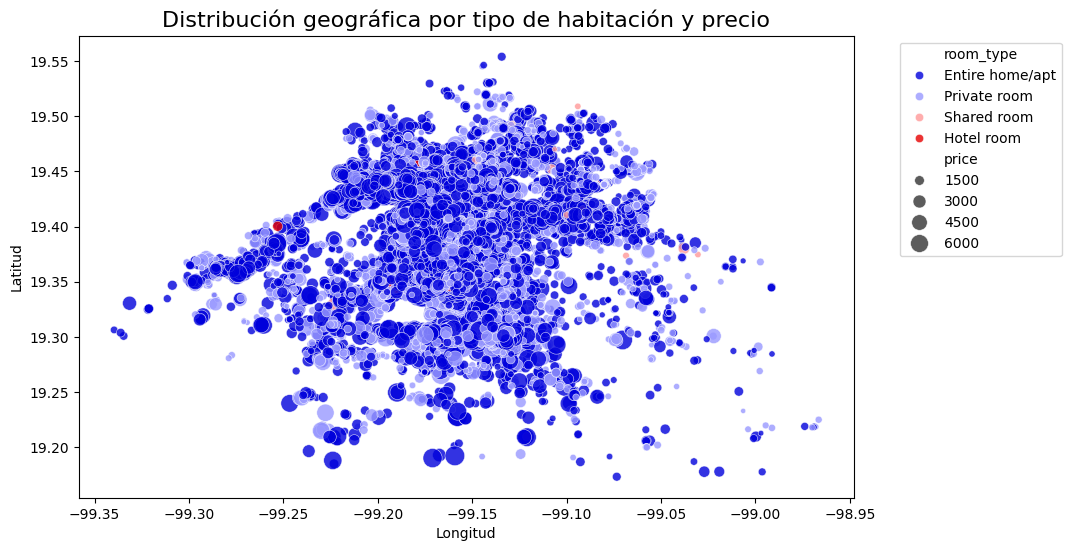

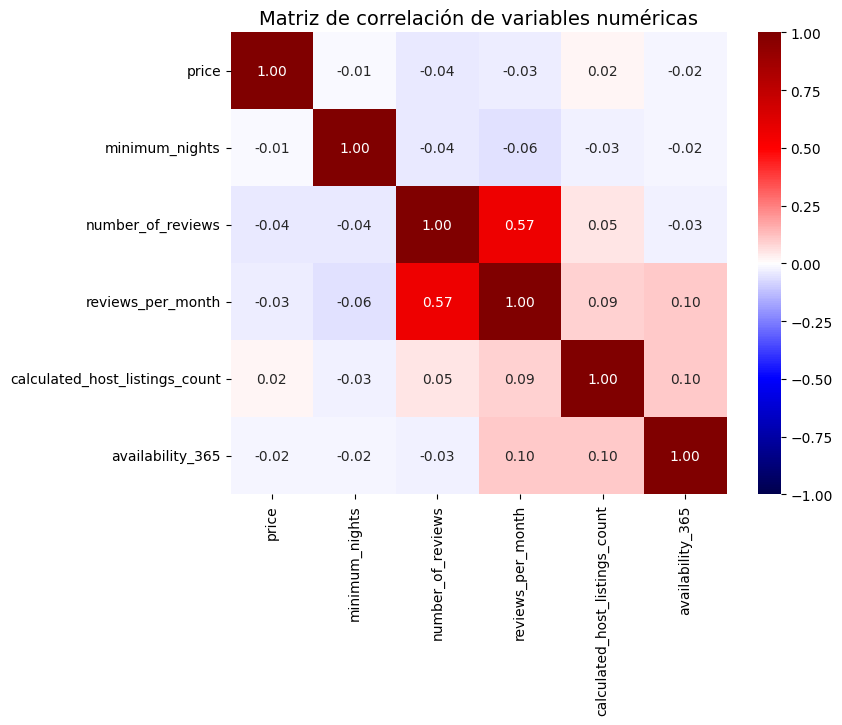

In [11]:
plt.figure(figsize=(10, 6))

#dispersión
sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='room_type',
    size='price',
    sizes=(10, 200),
    data=df_filtrado,
    palette='seismic',
    alpha=0.8
)

plt.title('Distribución geográfica por tipo de habitación y precio', fontsize=16)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#Matriz de correlación
plt.figure(figsize=(8, 6))
columnas_numericas = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
matriz_corr = df[columnas_numericas].corr()
sns.heatmap(matriz_corr, annot=True, cmap='seismic', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de correlación de variables numéricas', fontsize=14)
plt.show()

Distribución geográfica por tipo de habitación y precio.

La concentración principal de alojamientos se agrupa en el corredor central de la Ciudad de México, entre las latitudes 19.35 y 19.45, y longitudes -99.20 a -99.12.  

El color azul predomina en toda la zona urbana, lo que confirma que la oferta de alojamientos enteros prevalece en comparación con habitaciones privadas o compartidas.  
Los puntos de mayor tamaño con precios mayores no están dispersos, se concentran en el centro y la zona poniente de la ciudad.

Conforme se va más hacia los extremos de la ciudad, los círculos se reducen de tamaño, lo que muestra una disminución en los costos por noche.   

La variable `price` tiene valores cercanos a cero con todas las demás variables continuas (`minimum_nights`: -0.01, `number_of_reviews`: -0.04, `calculated_host_listings_count`: 0.02, `availability_365`: -0.02). Con eso se muestra que el precio por noche no depende de manera lineal de cuánto tiempo se alquila ni de cuántas reseñas recibe el listado.
La única correlación positiva moderada-fuerte se da entre `number_of_reviews` y `reviews_per_month `($r = 0.57$).
El ritmo sostenido de reseñas mensuales incrementa directamente el total acumulado de evaluaciones.   
Hay baja correlación entre la cantidad de propiedades que gestiona un anfitrión `calculated_host_listings_count` y la disponibilidad anual `availability_365` ($r = 0.10$) dice que tanto pequeños anfitriones como admnistradores de muchas propiedades trabajan bajo esquemas de disponibilidad parecidas en la plataforma.   

El dataset tiene mayoría de alojamientos de tipo *Entire home/apt* concentrados de manera geográfica en la zona central de la CDMX. Además, de una mediana de disponibilidad elevada de aproximadamente 299 días, la oferta en la plataforma está más orientada al uso de manera comercial continua más que a la economía colaborativa de manera ocasional.   
La matriz de correlación mostró que el precio no está necesariamente determinado por el número de reseñas, las noches mínimas o la cantidad de propiedades del anfitrión. El costo por noche está condicionado principalmente por factores cualitativos y espaciales como la ubicación geográfica y el tipo de habitación.   

La variable `price` presenta un sesgo con un máximo superior a $1,000,000$ MXN y la variable `minimum_nights` tiene valores no típicos imposibles para estancias cortas de hasta 729 noches.


Preguntas que abre el dataset:

* ¿Qué proporción del mercado de CDMX pertenece a anfitriones con administración de más de 3 o 5 propiedades en comparación a pequeños anfitriones?

* ¿Tiene un impacto económico directo el hecho de que la mayor concentración turística está en las alcaldías céntricas frente a las periféricas?
    
* ¿Cómo cambia el nivel de ocupación estimado que es medido a través de `reviews_per_month` según la ubicación geográfica dentro de la CDMX?

Problemas que requerirían corrección antes de un análisis posterior o modelado:

  Eliminar las 14 columnas que presentan el 100% de valores nulos tales como host_since, license, neighbourhood_group_cleansed, etc.) para optimizar el espacio de memoria. Además de los registros con reglas de estancia no realistas como `minimum_nights` > 365 y los listados con `price` = NaN o igual a cero.

**Declaración sobre el Uso de Inteligencia Artificial**

Para la realización de esta práctica se utilizó *Gemini (Google AI*) como herramienta de soporte técnico, pedagógico y de redacción.
Alcance de uso:
* Soporte de código y resolución de errores
  * Sugerencia de uso de la librería missingno para la visualización de patrón de datos.
* Comprensión de licencias.
* Supervisión de formato de texto.

